In [1]:
from dotenv import find_dotenv, load_dotenv

# Searches parent folders until it finds "local.env"
load_dotenv(find_dotenv("local.env"))

True

In [2]:
import tqdm as notebook_tqdm
from datasets.utils.logging import enable_progress_bar

enable_progress_bar()

## **1. Training a centralized model**

Centralized learning serves as our **theoretical performance ceiling (upper bound)**. All training data is pooled in a central repository, allowing standard globally shuffled mini-batch gradient descent.

### **A. Centralized Dataset Ingestion**

| Modality | Dataset | Input Resolution | Classes | Description |
| :--- | :--- | :--- | :--- | :--- |
| **Digits (Low Complexity)** | `ylecun/mnist` | $28 \times 28 \times 1$ | 10 | Grayscale digits, clear spatial boundaries. |
| **Objects (Medium Complexity)** | `uoft-cs/cifar10` | $32 \times 32 \times 3$ | 10 | RGB natural objects, high intra-class variance. |

---


In [3]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
from datasets import load_dataset

from models.simple_cnn import SimpleCNN

In [ ]:
def load_centralized_arrays(dataset_name, max_train=5000, max_test=1000, seed=42):
    """Load and normalize centralized train and test splits into JAX arrays."""
    train_ds = load_dataset(dataset_name, split="train")
    test_ds = load_dataset(dataset_name, split="test")

    img_key = "img" if "img" in train_ds.column_names else "image"

    def to_np(ds, limit):
        sub = ds.select(range(min(len(ds), limit)))
        imgs = [
            np.expand_dims(np.array(im, dtype=np.float32) / 255.0, -1)
            if np.array(im).ndim == 2
            else np.array(im, dtype=np.float32) / 255.0
            for im in sub[img_key]
        ]
        return jnp.array(np.stack(imgs)), jnp.array(
            np.array(sub["label"], dtype=np.int32)
        )

    x_train, y_train = to_np(train_ds, max_train)
    x_test, y_test = to_np(test_ds, max_test)
    return (x_train, y_train), (x_test, y_test)

In [ ]:
# JIT-compiled optimization and evaluation
@jax.jit
def train_step(state, batch_x, batch_y):
    def loss_fn(params):
        logits = state.apply_fn({"params": params}, batch_x, train=True)
        loss = optax.softmax_cross_entropy_with_integer_labels(
            logits=logits, labels=batch_y
        )
        return jnp.mean(loss)

    grad_fn = jax.grad(loss_fn)
    grads = grad_fn(state.params)
    return state.apply_gradients(grads=grads)

In [ ]:
@jax.jit
def eval_step(params, batch_x, batch_y):
    logits = SimpleCNN(num_classes=10).apply({"params": params}, batch_x, train=False)
    loss = jnp.mean(
        optax.softmax_cross_entropy_with_integer_labels(logits=logits, labels=batch_y)
    )
    preds = jnp.argmax(logits, axis=-1)
    acc = jnp.mean(preds == batch_y)
    return loss, acc

In [5]:
def train_centralized(dataset_name, epochs=10, batch_size=64, lr=1e-3):
    """Execute centralized training loop on pooled data."""
    (x_train, y_train), (x_test, y_test) = load_centralized_arrays(dataset_name)
    n_train = len(x_train)

    key = jax.random.PRNGKey(42)
    init_params = SimpleCNN(num_classes=10).init(key, x_train[:2], train=False)[
        "params"
    ]
    state = train_state.TrainState.create(
        apply_fn=SimpleCNN(num_classes=10).apply,
        params=init_params,
        tx=optax.adamw(lr),
    )

    history = {"epoch": [], "loss": [], "acc": []}

    for epoch in range(1, epochs + 1):
        perm = np.random.permutation(n_train)
        for s in range(0, n_train, batch_size):
            idx = perm[s : s + batch_size]
            state = train_step(state, x_train[idx], y_train[idx])

        loss, acc = eval_step(state.params, x_test, y_test)
        history["epoch"].append(epoch)
        history["loss"].append(float(loss))
        history["acc"].append(float(acc) * 100.0)
        print(
            f"  Epoch {epoch:02d} -> Test Acc: {float(acc) * 100:5.2f}% | Loss: {float(loss):.4f}"
        )

    return history, state.params

In [6]:
from flax.training import train_state

centralized_results = {}
for name in ["ylecun/mnist", "uoft-cs/cifar10"]:
    tag = "MNIST" if "mnist" in name else "CIFAR-10"
    print(f"\n[*] Training Centralized Model on {tag}...")
    hist, params = train_centralized(name, epochs=10)
    centralized_results[tag] = {"history": hist, "params": params}


[*] Training Centralized Model on MNIST...
  Epoch 01 -> Test Acc: 77.30% | Loss: 0.7013
  Epoch 02 -> Test Acc: 81.50% | Loss: 0.4980
  Epoch 03 -> Test Acc: 92.50% | Loss: 0.2555
  Epoch 04 -> Test Acc: 93.20% | Loss: 0.2072
  Epoch 05 -> Test Acc: 93.30% | Loss: 0.2103
  Epoch 06 -> Test Acc: 94.10% | Loss: 0.1617
  Epoch 07 -> Test Acc: 94.10% | Loss: 0.1933
  Epoch 08 -> Test Acc: 95.10% | Loss: 0.1423
  Epoch 09 -> Test Acc: 94.20% | Loss: 0.1498
  Epoch 10 -> Test Acc: 96.10% | Loss: 0.1162

[*] Training Centralized Model on CIFAR-10...
  Epoch 01 -> Test Acc: 23.80% | Loss: 2.0008
  Epoch 02 -> Test Acc: 30.00% | Loss: 1.8489
  Epoch 03 -> Test Acc: 35.00% | Loss: 1.7231
  Epoch 04 -> Test Acc: 40.10% | Loss: 1.6550
  Epoch 05 -> Test Acc: 37.40% | Loss: 1.6604
  Epoch 06 -> Test Acc: 42.50% | Loss: 1.5240
  Epoch 07 -> Test Acc: 42.20% | Loss: 1.6206
  Epoch 08 -> Test Acc: 42.40% | Loss: 1.5561
  Epoch 09 -> Test Acc: 44.10% | Loss: 1.5028
  Epoch 10 -> Test Acc: 44.40% | Lo

### **B. Centralized Convergence Visualizations**


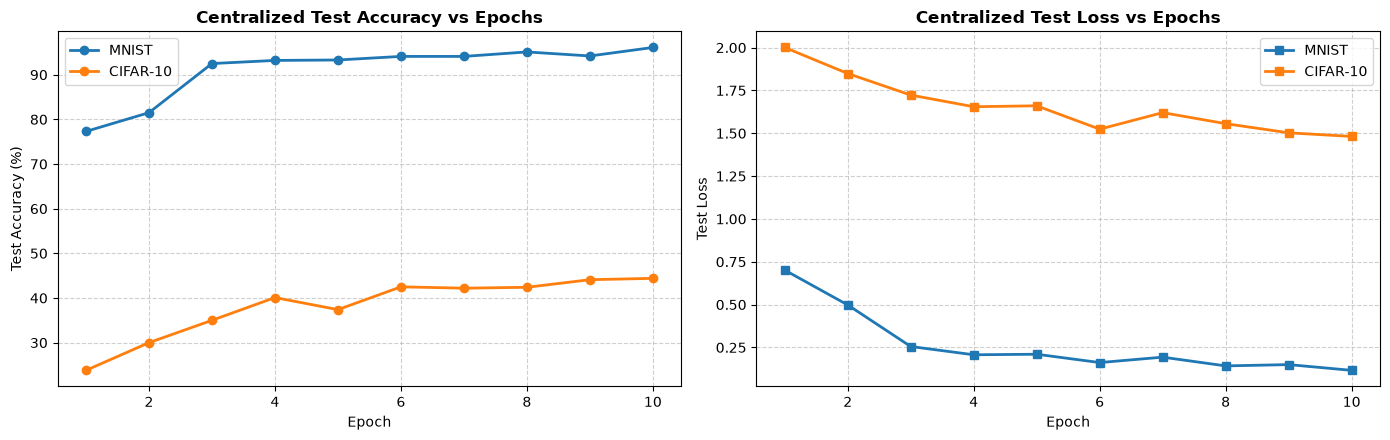

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Accuracy Curves
for tag, data in centralized_results.items():
    h = data["history"]
    axes[0].plot(h["epoch"], h["acc"], marker="o", linewidth=2, label=f"{tag}")
axes[0].set_title("Centralized Test Accuracy vs Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Accuracy (%)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# Loss Curves
for tag, data in centralized_results.items():
    h = data["history"]
    axes[1].plot(h["epoch"], h["loss"], marker="s", linewidth=2, label=f"{tag}")
axes[1].set_title("Centralized Test Loss vs Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test Loss")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## **2. Training a federated model**

Now we simulate decentralized learning across $K = 5$ edge clients under an **ideal IID partition** using `IidPartitioner`.

### **A. Federated Partitions Setup**


In [8]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import IidPartitioner
from flwr_datasets.visualization import plot_label_distributions

In [9]:
num_clients = 5

fds_fed = {
    "MNIST": FederatedDataset(
        dataset="ylecun/mnist",
        partitioners={"train": IidPartitioner(num_partitions=num_clients)},
    ),
    "CIFAR-10": FederatedDataset(
        dataset="uoft-cs/cifar10",
        partitioners={"train": IidPartitioner(num_partitions=num_clients)},
    ),
}

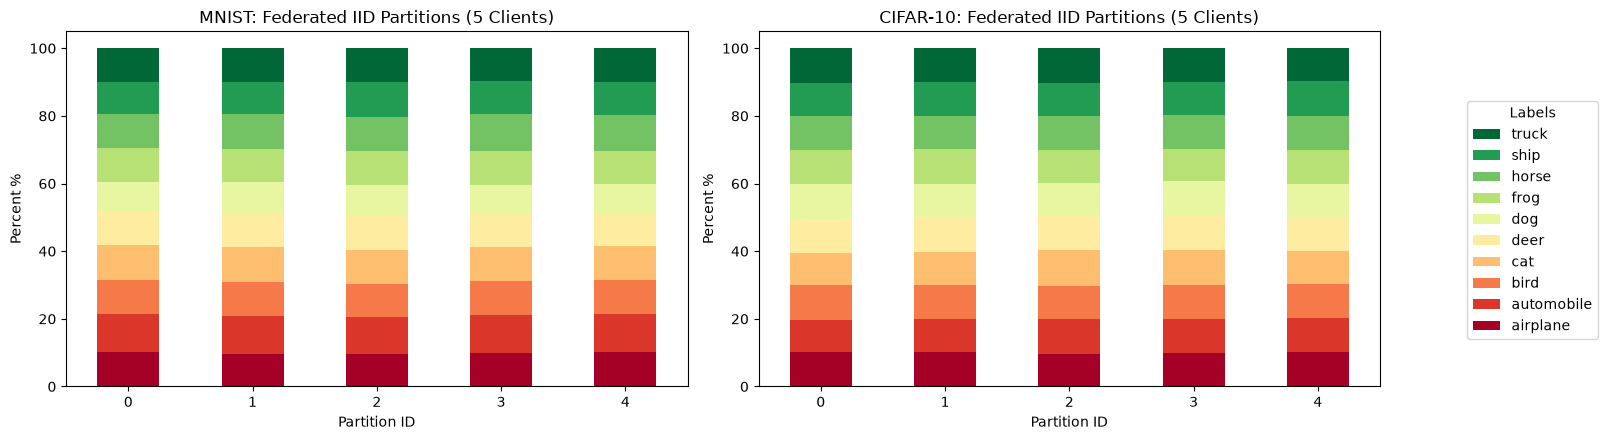

In [10]:
# Visualizing partition distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for idx, (tag, fds) in enumerate(fds_fed.items()):
    plot_label_distributions(
        partitioner=fds.partitioners["train"],
        label_name="label",
        plot_type="bar",
        size_unit="percent",
        axis=axes[idx],
        title=f"{tag}: Federated IID Partitions (5 Clients)",
        legend=(idx == 1),
    )

plt.tight_layout()
plt.show()

In [11]:
def train_federated(fds, dataset_name, rounds=10, local_epochs=1, batch_size=64):
    """Simulate multi-round Federated Averaging (FedAvg) with K clients."""
    # Extract client data partitions
    img_key = "img" if "cifar" in dataset_name else "image"
    client_data = []
    for i in range(num_clients):
        part = fds.load_partition(i, split="train")
        sub = part.select(range(min(len(part), 1000)))
        imgs = [
            np.expand_dims(np.array(im, dtype=np.float32) / 255.0, -1)
            if np.array(im).ndim == 2
            else np.array(im, dtype=np.float32) / 255.0
            for im in sub[img_key]
        ]
        client_data.append(
            (
                jnp.array(np.stack(imgs)),
                jnp.array(np.array(sub["label"], dtype=np.int32)),
            )
        )

    # Centralized evaluation test set
    _, test_data = load_centralized_arrays(dataset_name, max_test=1000)

    key = jax.random.PRNGKey(42)
    params = SimpleCNN(num_classes=10).init(key, client_data[0][0][:2], train=False)[
        "params"
    ]
    history = {"round": [], "acc": [], "loss": []}

    for rnd in range(1, rounds + 1):
        local_params = []
        for cx, cy in client_data:
            state = train_state.TrainState.create(
                apply_fn=SimpleCNN(num_classes=10).apply,
                params=params,
                tx=optax.adamw(1e-3),
            )
            n = len(cx)
            for _ in range(local_epochs):
                perm = np.random.permutation(n)
                for s in range(0, n, batch_size):
                    idx = perm[s : s + batch_size]
                    state = train_step(state, cx[idx], cy[idx])
            local_params.append(state.params)

        # FedAvg: Parameter averaging
        params = jax.tree_util.tree_map(
            lambda *p_trees: sum(p for p in p_trees) / len(p_trees),
            *local_params,
        )

        loss, acc = eval_step(params, test_data[0], test_data[1])
        history["round"].append(rnd)
        history["acc"].append(float(acc) * 100.0)
        history["loss"].append(float(loss))
        print(
            f"  Round {rnd:02d} -> Test Acc: {float(acc) * 100:5.2f}% | Loss: {float(loss):.4f}"
        )

    return history, params

In [12]:
federated_results = {}
for tag, fds in fds_fed.items():
    hub_name = "ylecun/mnist" if tag == "MNIST" else "uoft-cs/cifar10"
    print(f"\n[*] Training Federated Model (FedAvg) on {tag}...")
    hist, params = train_federated(fds, hub_name, rounds=10)
    federated_results[tag] = {"history": hist, "params": params}


[*] Training Federated Model (FedAvg) on MNIST...
  Round 01 -> Test Acc: 47.10% | Loss: 2.1676
  Round 02 -> Test Acc: 59.00% | Loss: 1.6154
  Round 03 -> Test Acc: 71.90% | Loss: 1.2183
  Round 04 -> Test Acc: 78.60% | Loss: 0.9361
  Round 05 -> Test Acc: 82.20% | Loss: 0.7299
  Round 06 -> Test Acc: 84.20% | Loss: 0.6100
  Round 07 -> Test Acc: 86.10% | Loss: 0.5218
  Round 08 -> Test Acc: 86.30% | Loss: 0.4868
  Round 09 -> Test Acc: 86.80% | Loss: 0.4331
  Round 10 -> Test Acc: 88.30% | Loss: 0.3908

[*] Training Federated Model (FedAvg) on CIFAR-10...
  Round 01 -> Test Acc: 10.90% | Loss: 2.2780
  Round 02 -> Test Acc: 23.90% | Loss: 2.1143
  Round 03 -> Test Acc: 24.80% | Loss: 1.9909
  Round 04 -> Test Acc: 28.90% | Loss: 1.9585
  Round 05 -> Test Acc: 29.70% | Loss: 1.9436
  Round 06 -> Test Acc: 29.80% | Loss: 1.9050
  Round 07 -> Test Acc: 31.20% | Loss: 1.8865
  Round 08 -> Test Acc: 32.80% | Loss: 1.8613
  Round 09 -> Test Acc: 34.60% | Loss: 1.8199
  Round 10 -> Test Ac

## **3. Comparison of Key performance metrics**

### **A. Metrics Summary Table**


In [13]:
import pandas as pd

rows = []
for tag in ["MNIST", "CIFAR-10"]:
    c_acc = centralized_results[tag]["history"]["acc"][-1]
    c_loss = centralized_results[tag]["history"]["loss"][-1]
    f_acc = federated_results[tag]["history"]["acc"][-1]
    f_loss = federated_results[tag]["history"]["loss"][-1]
    gap = c_acc - f_acc

    rows.append(
        {
            "Dataset": tag,
            "Centralized Acc (%)": round(c_acc, 2),
            "Centralized Loss": round(c_loss, 4),
            "Federated Acc (%)": round(f_acc, 2),
            "Federated Loss": round(f_loss, 4),
            "Decentralization Gap (%p)": round(gap, 2),
        }
    )

metrics_df = pd.DataFrame(rows)
metrics_df

,Dataset,Centralized Acc (%),Centralized Loss,Federated Acc (%),Federated Loss,Decentralization Gap (%p)
0,MNIST,96.1,0.1162,88.3,0.3908,7.8
1,CIFAR-10,44.4,1.4816,33.4,1.8025,11.0


### **B. Overlay Trajectory Comparison**

Direct comparison of Centralized SGD (over epochs) vs Federated Averaging (over communication rounds):


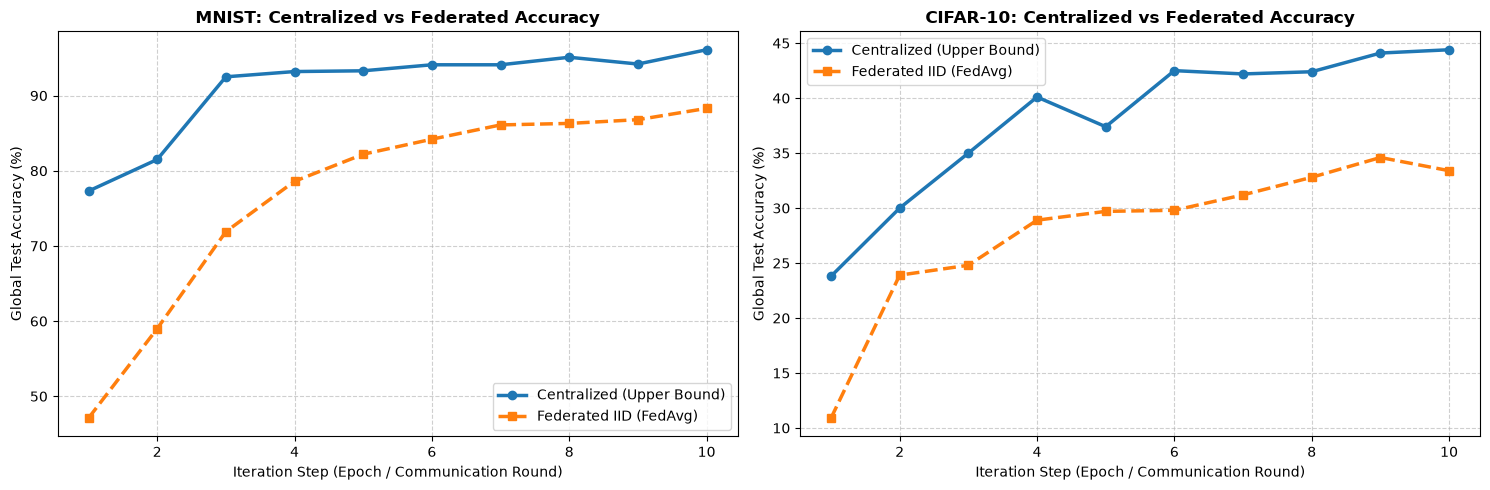

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, tag in enumerate(["MNIST", "CIFAR-10"]):
    c_h = centralized_results[tag]["history"]
    f_h = federated_results[tag]["history"]

    axes[idx].plot(
        c_h["epoch"],
        c_h["acc"],
        marker="o",
        linewidth=2.5,
        label="Centralized (Upper Bound)",
        color="#1f77b4",
    )
    axes[idx].plot(
        f_h["round"],
        f_h["acc"],
        marker="s",
        linewidth=2.5,
        linestyle="--",
        label="Federated IID (FedAvg)",
        color="#ff7f0e",
    )
    axes[idx].set_title(f"{tag}: Centralized vs Federated Accuracy", fontweight="bold")
    axes[idx].set_xlabel("Iteration Step (Epoch / Communication Round)")
    axes[idx].set_ylabel("Global Test Accuracy (%)")
    axes[idx].legend(frameon=True, facecolor="white")
    axes[idx].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### **C. Decentralization Penalty by Modality**


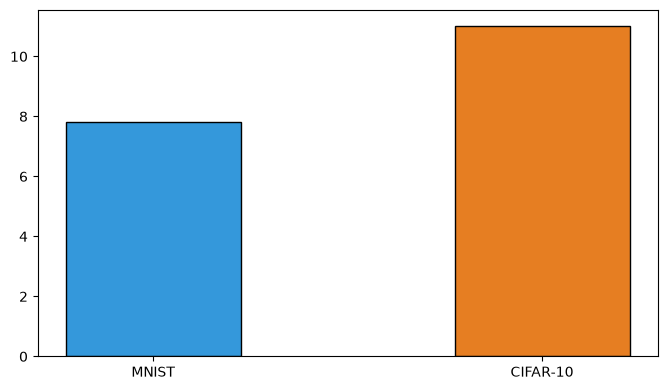

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    metrics_df["Dataset"],
    metrics_df["Decentralization Gap (%p)"],
    color=["#3498db", "#e67e22"],
    edgecolor="black",
    width=0.45,
)

In [16]:
for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.3,
        f"{yval:+.2f}%p",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_title(
    "Decentralization Gap ($Acc_{Centralized} - Acc_{Fed-IID}$)", fontweight="bold"
)
ax.set_ylabel("Accuracy Penalty (% points)")
ax.set_ylim(0, max(metrics_df["Decentralization Gap (%p)"]) + 3)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### **D. Key Insights & Takeaways**

* **Privacy vs Performance Trade-off:** Federated learning preserves data locality across clients at the cost of a modest decentralization penalty compared to pooled centralized SGD.
* **Modality Robustness:** On structured datasets like MNIST, Federated IID closely matches Centralized accuracy with negligible degradation. On complex RGB datasets like CIFAR-10, the gap is wider due to periodic parameter averaging instead of continuous gradient updates.
* **Next Step:** Having established the Centralized Upper Bound and Federated IID baseline, notebook `02-iid-vs-noniid.ipynb` investigates how **statistical data heterogeneity (Non-IID skew)** further impacts this performance gap.
